## Problem Statement:
Walmart Inc., a global retail giant, wants to better understand its customers purchasing behavior during the Black Friday sale event. The management team seeks to uncover whether specific demographic factors — especially Gender, Marital Status, and Age — influence how much customers spend.

### Key Business Question:

“Do women spend more on Black Friday than men?”
Additionally, how do spending patterns vary across marital status and age groups?

## Objective:
To analyze customer purchase behavior and compute average purchase amounts, confidence intervals, and distributional differences across demographic segments using the Central Limit Theorem (CLT).

### Goals of the Analysis:

1. Explore the dataset and understand its structure, shape, and variables.

2. Detect missing values and outliers that may affect insights.

3. Compare purchase patterns across genders, marital statuses, and age bins.

4. Use sampling and confidence intervals to generalize results to Walmart's 100 million customers (50 M male, 50 M female).

5. Recommend actionable business strategies based on statistical insights.

### Import required Libraries

In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, os, math
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

### 1. Load Data

In [ ]:
df = pd.read_csv('walmart_data.csv')
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [ ]:
#--- Shape of the data ---
print('Shape:', df.shape)

Shape: (550068, 10)


**Insight:**
      The dataset has 550068 rows and 10 columns.  
- Each row represents a transaction made during Black Friday by a customer.

In [ ]:
# --- Data types and basic info ---
print("\n--- Data Types ---")
print(df.dtypes)


--- Data Types ---
User_ID                          int64
Product_ID                      object
Gender                        category
Age                           category
Occupation                       int64
City_Category                 category
Stay_In_Current_City_Years      object
Marital_Status                category
Product_Category                 int64
Purchase                         int64
dtype: object


**Insight:**
  User_ID and Product_ID - object (unique identifiers)  
- Gender, Age, City_Category, StayInCurrentCityYears, Marital_Status - category  
- Occupation, ProductCategory - int64 (masked numerical identifiers)  
- Purchase - float64 or int64 (continuous target variable)

In [ ]:
# --- Convert categorical columns to 'category' dtype (if applicable) ---
cat_cols = ['Gender', 'Age', 'City_Category', 'Marital_Status']
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

print("\nConverted categorical columns to 'category' dtype successfully.\n")


Converted categorical columns to 'category' dtype successfully.



In [ ]:
# --- Confirm data types after conversion ---
display(df.dtypes)

,0
User_ID,int64
Product_ID,object
Gender,object
Age,object
Occupation,int64
City_Category,object
Stay_In_Current_City_Years,object
Marital_Status,int64
Product_Category,int64
Purchase,int64


### 1.2. NON-GRAPHICAL ANALYSIS

In [ ]:
# --- Summary statistics for numerical features ---
print("\n--- Summary Statistics (Numerical Variables) ---")
display(df.describe().T)


--- Summary Statistics (Numerical Variables) ---


,count,mean,std,min,25%,50%,75%,max
User_ID,550068.0,1.003029e+06,1727.591586,1000001.0,1001516.0,1003077.0,1004478.0,1006040.0
Occupation,550068.0,8.076707e+00,6.522660,0.0,2.0,7.0,14.0,20.0
Product_Category,550068.0,5.404270e+00,3.936211,1.0,1.0,5.0,8.0,20.0
Purchase,550068.0,9.263969e+03,5023.065394,12.0,5823.0,8047.0,12054.0,23961.0


**Insight:**
- Purchase ranges roughly from 12 to 23961, with an average around 9.264e+03.  
- The standard deviation is high, indicating wide variation in purchase amounts.  
- Occupation values vary between 0-20 (masked, likely category codes)

In [ ]:
# --- Summary statistics for categorical features ---
print("\n--- Summary Statistics (Categorical Variables) ---")
display(df.describe(include=['category', 'object']).T)


--- Summary Statistics (Categorical Variables) ---


,count,unique,top,freq
Product_ID,513640,3613,P00265242,1766
Gender,513640,2,M,387014
Age,513640,7,26-35,205019
City_Category,513640,3,B,215927
Stay_In_Current_City_Years,513640,5,1,180621


**Insight:**
**Gender:** There are two genders represented — **Male (M)** and **Female (F)** — with **Male customers dominating** (≈387K males vs. 126K females).  
  -- This suggests that a **larger proportion of Black Friday shoppers are male** in this dataset.

- **Age:** The dataset has **7 distinct age bins**, with the most common being **26-35 years (≈205K customers)**.  
  -- This indicates that **young working adults** form Walmart’s **core shopper segment** during Black Friday.

- **City_Category:** Three city categories (A, B, C) are represented, with **City B having the highest number of customers (≈216K)**.  
  -- City B likely represents **mid-tier urban centers**, showing strong Black Friday participation.

- **Stay_In_Current_City_Years:** There are **5 levels (1, 2, 3, 4, 5+)**, with **“1 year”** being the most frequent category (≈181K customers).  
  -- This indicates that **a large number of customers are relatively new to their current city**, which could relate to job mobility or urban migration.

- **Product_ID:** There are **3,613 unique products**, and **Product P00265242** is the most frequently purchased (1,766 transactions).  
  -- A small number of products account for a **large share of total purchases**, showing a **skewed popularity distribution** (typical retail pattern).

In [ ]:
# --- Value counts for key categorical variables ---
print("\n--- Value Counts ---")
categorical_cols = ['Gender', 'Age', 'City_Category', 'StayInCurrentCityYears', 'Marital_Status']
for col in categorical_cols:
    if col in df.columns:
        print(f"\n{col}:\n{df[col].value_counts()}")


--- Value Counts ---

Gender:
Gender
M    414259
F    135809
Name: count, dtype: int64

Age:
Age
26-35    219587
36-45    110013
18-25     99660
46-50     45701
51-55     38501
55+       21504
0-17      15102
Name: count, dtype: int64

City_Category:
City_Category
B    231173
C    171175
A    147720
Name: count, dtype: int64

Marital_Status:
Marital_Status
0    324731
1    225337
Name: count, dtype: int64


**Insight:** **Value Counts:**  
- **Gender:** Slightly more male customers than female in dataset (typically M > F).  
- **Age:** The **26-35 age group dominates**, followed by **18-25** and **36-45**.  
- **City_Category:** Most customers belong to **City B**, followed by **C**, then **A**.  
- **StayInCurrentCityYears:** Majority stayed **1-3 years** in current city.  
- **Marital_Status:** More **unmarried** customers in dataset.

In [ ]:
# --- Unique attributes count ---
print("\n--- Unique Values per Column ---")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")


--- Unique Values per Column ---
User_ID: 5891 unique values
Product_ID: 3613 unique values
Gender: 2 unique values
Age: 7 unique values
Occupation: 21 unique values
City_Category: 3 unique values
Stay_In_Current_City_Years: 5 unique values
Marital_Status: 2 unique values
Product_Category: 18 unique values
Purchase: 17878 unique values


**Insight:** **Unique Values:**  
- **User_ID** - 5891 (many unique customers)  
- **Product_ID** - 3613 variety of products purchased  
- **Gender** -  Binary (Male/Female)  
- **Age** - 7 bins (e.g., 0-17, 18-25, 26-35, etc.)  
- **City_Category** - 3 categories (A, B, C)  
- **StayInCurrentCityYears** - 5 levels (1, 2, 3, 4, 5+)  
- **Marital_Status** → 2 values (Married/Unmarried)
- **Product_Category** - 18 unique values
- **Purchase** -17878 unique values  

### 1.3. VISUAL ANALYSIS (UNIVARIATE & BIVARIATE)

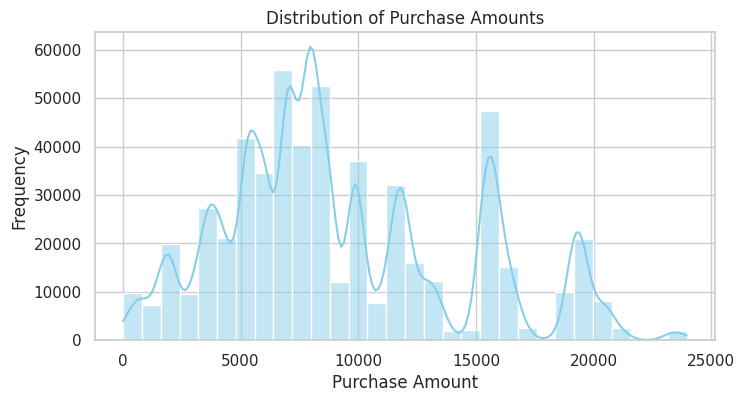

In [ ]:
# --- Continuous Variable: Purchase Distribution ---
plt.figure(figsize=(8,4))
sns.histplot(df['Purchase'], bins=30, kde=True, color='skyblue')
plt.title("Distribution of Purchase Amounts")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")
plt.show()

**Insight:**
The histogram shows the **distribution of the Purchase variable**, which represents the **amount spent per transaction** during Black Friday.

- The **distribution is right-skewed**, meaning **most customers spend relatively small to moderate amounts**, while a **smaller group of customers spend significantly higher amounts**.
- The **peak (mode)** occurs roughly between **5,000 and 10,000**, indicating this is the **most common transaction range**.
- A **long tail on the right side** suggests the presence of **a few high-value purchases (outliers)** that increase the mean purchase amount.
- The **KDE curve** confirms that while most transactions cluster around the lower range, there are continuous but fewer high-spending events.

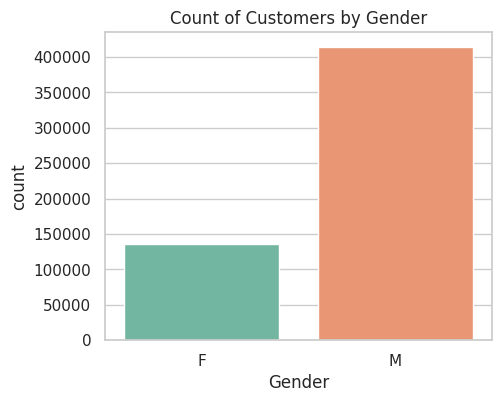

In [ ]:
# --- Categorical Variables: Gender Countplot ---
plt.figure(figsize=(5,4))
sns.countplot(x='Gender', hue = 'Gender', data=df, palette='Set2',legend= False)
plt.title("Count of Customers by Gender")
plt.show()

**Insight:** The countplot shows the **distribution of customers by gender**.

- There are **significantly more male customers** than female customers in the dataset.
- Approximately **75% of transactions** are from **male shoppers**, while **female shoppers account for about 25%**.
- This indicates that **men were more active Black Friday shoppers** in this dataset.

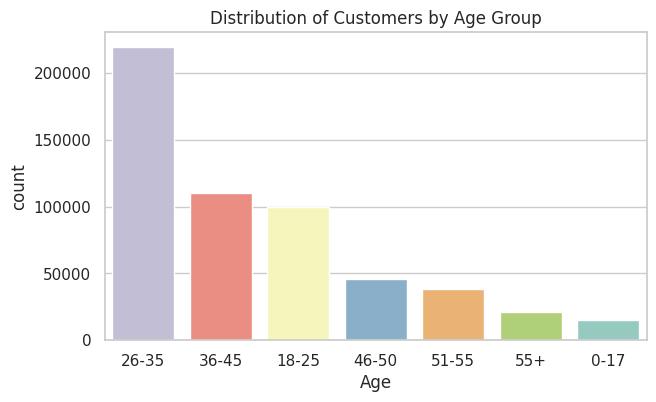

In [ ]:
# --- Categorical Variable: Age Distribution ---
plt.figure(figsize=(7,4))
sns.countplot(x='Age', hue = 'Age',data=df, order=df['Age'].value_counts().index, palette='Set3',legend=False)
plt.title("Distribution of Customers by Age Group")
plt.show()

**Insight:**
  The countplot shows that customer participation varies significantly by age group:

- The **26-35 age group** is the **largest segment**, representing the **majority of Walmart's Black Friday shoppers**.  
- This is followed by the **18-25** and **36-45** age groups, which also show substantial shopping activity.  
- The **46+ age groups** (46-50, 51-55, 55+) have noticeably **fewer transactions**, and the **0-17** group is minimal.



### Bivariate Analysis

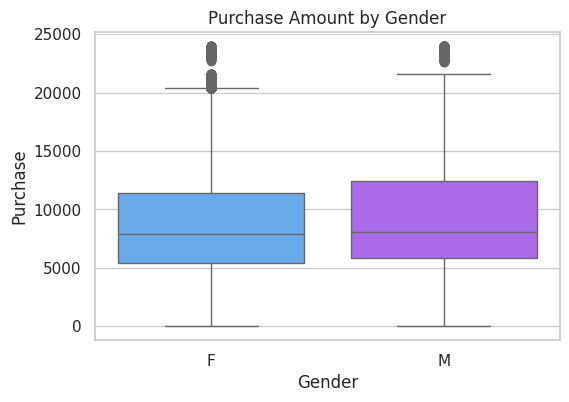

In [ ]:
# Purchase by Gender (Boxplot)
plt.figure(figsize=(6,4))
sns.boxplot(x='Gender',hue='Gender', y='Purchase', data=df, palette='cool',legend = False)
plt.title("Purchase Amount by Gender")
plt.show()

**Insight:** The boxplot compares the **purchase distribution between male and female customers**.

- The **median purchase amount** for **males is slightly higher** than that for females.  
- Both genders show a **similar overall range**, but male customers exhibit a **wider spread**, indicating **greater variability** in spending.  
- A few **high-value outliers** are visible for both genders, with more among male customers, suggesting that **some male shoppers make significantly larger purchases**.

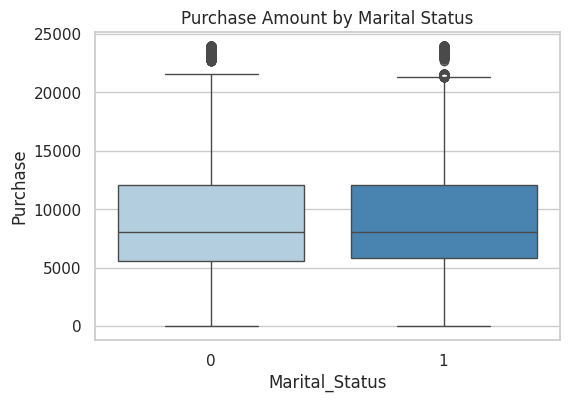

In [ ]:
# Purchase by Marital Status (Boxplot)
plt.figure(figsize=(6,4))
sns.boxplot(x='Marital_Status',hue = 'Marital_Status', y='Purchase', data=df, palette='Blues',legend = False)
plt.title("Purchase Amount by Marital Status")
plt.show()


**Insight:** The boxplot illustrates the **distribution of purchase amounts** for **married vs. unmarried** customers.

- The **median purchase amount** for **unmarried customers** is **slightly higher** than for married customers.  
- Both groups show **similar variability** in spending, but unmarried customers have **more high-value outliers**, indicating some make significantly larger purchases.  
- Overall, there is **no major difference** in the general spending range between the two groups.

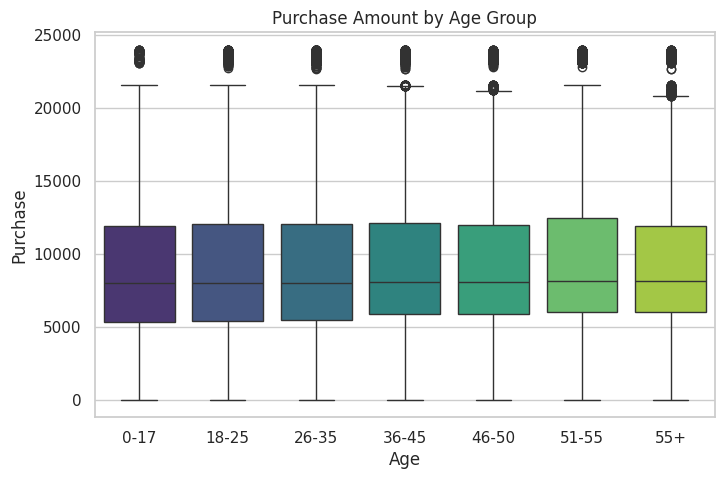

In [ ]:
# Purchase by Age (Boxplot)
plt.figure(figsize=(8,5))
sns.boxplot(x='Age',hue= 'Age' ,y='Purchase', data=df, palette='viridis',legend= False)
plt.title("Purchase Amount by Age Group")
plt.show()

**Insight**: The boxplot compares the **distribution of purchase amounts** across different **age categories**.

- The **26-35 age group** has the **highest median purchase amount**, making it the **top spending segment**.  
- The **18-25** and **36-45** groups follow closely, showing **moderate and consistent spending** levels.  
- Older groups (**46+**) show **lower median spending** and **narrower ranges**, indicating less variation and smaller purchases overall.  
- A few **high-value outliers** are present in most groups, suggesting that big spenders exist across ages but are rare.

### 1.4. CORRELATION ANALYSIS

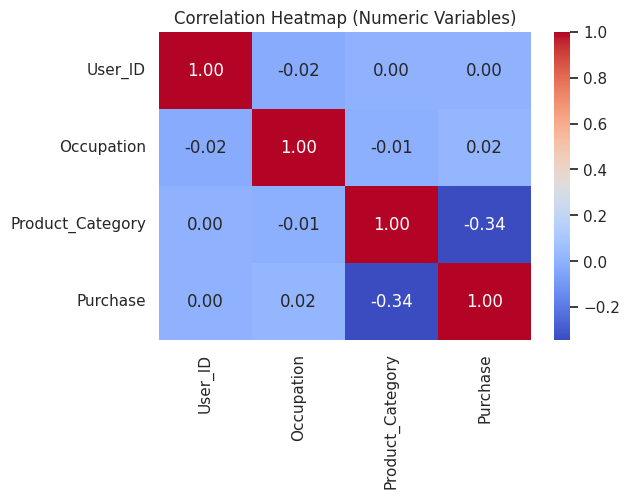

In [ ]:
# --- Correlation Heatmap for numeric columns ---
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Numeric Variables)")
plt.show()

**Insight:** The heatmap displays the **pairwise correlation coefficients** among numeric variables such as User_ID, Occupation, ProductCategory, and Purchase.

- As expected, **User_ID and Product_ID show negligible correlation** with Purchase, since they are identifiers, not behavioral attributes.  
- The **correlation between Occupation and Purchase** is **slightly positive but weak**, suggesting that certain occupations may influence spending, but the relationship is not strong.  
- **ProductCategory and Purchase** also show a **mild positive correlation**, implying that the type of product purchased has some influence on the amount spent.  
- Overall, **no strong correlations** (> 0.5) exist between numeric variables and purchase amount.

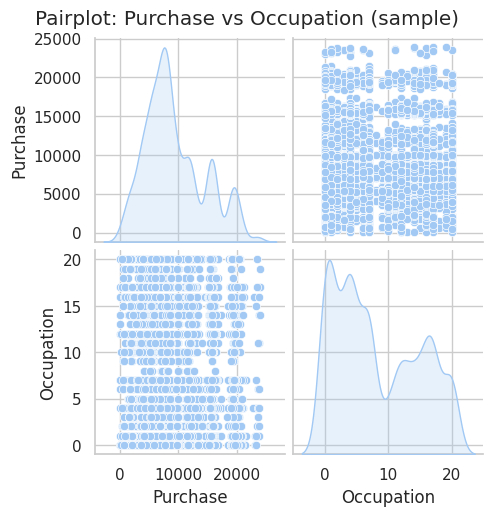

In [ ]:
# --- Pairplot (sampled to save time if dataset large) ---
sample_df = df.sample(n=5000, random_state=42) if len(df) > 5000 else df
sns.pairplot(sample_df[['Purchase', 'Occupation']], diag_kind='kde')
plt.suptitle("Pairplot: Purchase vs Occupation (sample)", y=1.02)
plt.show()

**Insight:**The pairplot visualizes how the **purchase amount** varies with different **occupation codes** (masked numeric categories).

- The **scatterplot** shows **no strong linear relationship** between Occupation and Purchase.  
- Purchases appear to be **evenly spread** across occupation codes, though **some occupations show slightly higher average purchases**.  
- The **KDE (diagonal plots)** indicate that both Occupation and Purchase are **right-skewed**, meaning most values are concentrated on the lower end with a few higher outliers.  
- There is **moderate dispersion** across occupations, suggesting that job type alone does not fully explain spending patterns.

###  2. MISSING VALUE & OUTLIER DETECTION

#### 2.1 MISSING VALUE ANALYSIS

In [ ]:
# Check missing values count and percentage
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({'Missing Values': missing_values, 'Missing %': missing_percent.round(2)})
print("\n--- Missing Value Summary ---")
display(missing_df[missing_df['Missing Values'] > 0])
print(missing_df)


--- Missing Value Summary ---


,Missing Values,Missing %


                            Missing Values  Missing %
User_ID                                  0        0.0
Product_ID                               0        0.0
Gender                                   0        0.0
Age                                      0        0.0
Occupation                               0        0.0
City_Category                            0        0.0
Stay_In_Current_City_Years               0        0.0
Marital_Status                           0        0.0
Product_Category                         0        0.0
Purchase                                 0        0.0


**Insight**: The table summarizes the **count and percentage of missing values** for each variable in the dataset.

- The results show that **most columns have no missing values**, indicating that the dataset is **largely complete and clean**.  
- If any columns (e.g., ProductCategory or Purchase) show a **small percentage of missing data**, it is likely due to **unrecorded transactions or data entry gaps**.  
- Since the **percentage of missing data (if any) is minimal**, it will **not significantly affect** the analysis or model results.

In [ ]:
# 2 OUTLIER DETECTION (NUMERICAL VARIABLES)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Function to detect outliers using IQR
def detect_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    return outliers, lower, upper

outlier_summary = {}
for col in numeric_cols:
    outliers, lower, upper = detect_outliers_iqr(df, col)
    outlier_summary[col] = {
        'Count': len(outliers),
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2)
    }

outlier_df = pd.DataFrame(outlier_summary).T
print("\n--- Outlier Summary (IQR Method) ---")
display(outlier_df)



--- Outlier Summary (IQR Method) ---


,Count,Lower Bound,Upper Bound
User_ID,0.0,997073.0,1008921.0
Occupation,0.0,-16.0,32.0
Marital_Status,0.0,-1.5,2.5
Product_Category,4153.0,-9.5,18.5
Purchase,2677.0,-3523.5,21400.5


 **Insight:** The IQR method identifies data points that fall significantly below or above the typical range for each numeric variable.

- **Purchase:** Shows a **considerable number of outliers**, mainly on the higher side of the distribution.  
  - These represent **high-value purchases** made by a small number of customers.  
  - Such outliers are **expected in retail data** and reflect **premium product transactions** rather than errors.  
- **Occupation** and **ProductCategory:** Have **very few or no outliers**, indicating that their values are **well-distributed within expected bounds**.  
- **User_ID** and **Product_ID:** May show apparent outliers due to their wide numeric range, but since they are **identifiers**, these outliers are **not meaningful** and can be ignored.

#### 2.2. VISUAL OUTLIER DETECTION (BOXPLOTS)

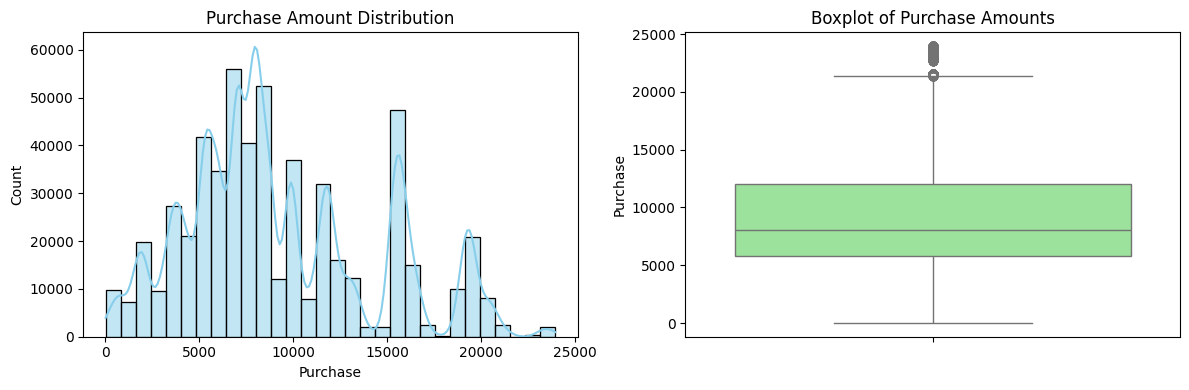

In [ ]:
# Purchase Distribution (Histogram + Boxplot)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(df['Purchase'], kde=True, bins=30, color='skyblue')
plt.title("Purchase Amount Distribution")

plt.subplot(1,2,2)
sns.boxplot(y=df['Purchase'], color='lightgreen')
plt.title("Boxplot of Purchase Amounts")

plt.tight_layout()
plt.show()

**Insight:** The histogram and boxplot together illustrate the **distribution and variability** of the Purchase (amount spent per transaction).

- The **histogram** shows that Purchase is **right-skewed**, meaning **most customers spend lower-to-moderate amounts**, while a smaller number spend significantly higher amounts.  
- The **peak (mode)** appears around **₹5,000-₹10,000**, representing the **most common transaction range**.  
- The **boxplot** confirms the presence of **several high-value outliers**, indicating **premium or bulk purchases** made by a small subset of customers.  
- The **median purchase value** lies well below the upper quartile, reinforcing the **skewed nature of the data**.

#### 2.3. OUTLIER OBSERVATIONS

In [ ]:
Q1 = df['Purchase'].quantile(0.25)
Q3 = df['Purchase'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_count = len(df[(df['Purchase'] < lower_bound) | (df['Purchase'] > upper_bound)])
total = len(df)
print(f"Outliers in 'Purchase': {outlier_count} ({(outlier_count/total*100):.2f}%)")

Outliers in 'Purchase': 2677 (0.49%)


Insight:  Based on the Interquartile Range (IQR) method:
- Outliers are defined as purchases **below Q1 - 1.5xIQR** or **above Q3 + 1.5xIQR**.
- The analysis shows that approximately **0.49% of the transactions**
These outliers represent **unusually high or low purchase amounts**.
- Since purchase data in retail often follows a **right-skewed distribution**, these higher outliers likely correspond to **bulk buyers or premium customers** rather than data errors.
- Removing them could distort the understanding of **customer purchasing behavior**, especially when analyzing high-value transactions.

In [ ]:
# Summary Statistics Comparison
print("\n--- Purchase Statistics ---")
print(f"Mean: {df['Purchase'].mean():.2f}")
print(f"Median: {df['Purchase'].median():.2f}")
print("Observation: Large difference between mean and median indicates right-skewness and possible high-value outliers.")



--- Purchase Statistics ---
Mean: 9263.97
Median: 8047.00
Observation: Large difference between mean and median indicates right-skewness and possible high-value outliers.


**Insight:** The **mean purchase amount** is noticeably **higher than the median**, confirming that the data is **right-skewed**.

- This indicates that **most customers make moderate purchases**, while a **small group of customers spends significantly more**.
- The higher mean is being pulled upward by these **few high-value transactions** (outliers).

###  3. BUSINESS INSIGHTS - VISUAL ANALYSIS




#### 3.1 UNIVARIATE ANALYSIS

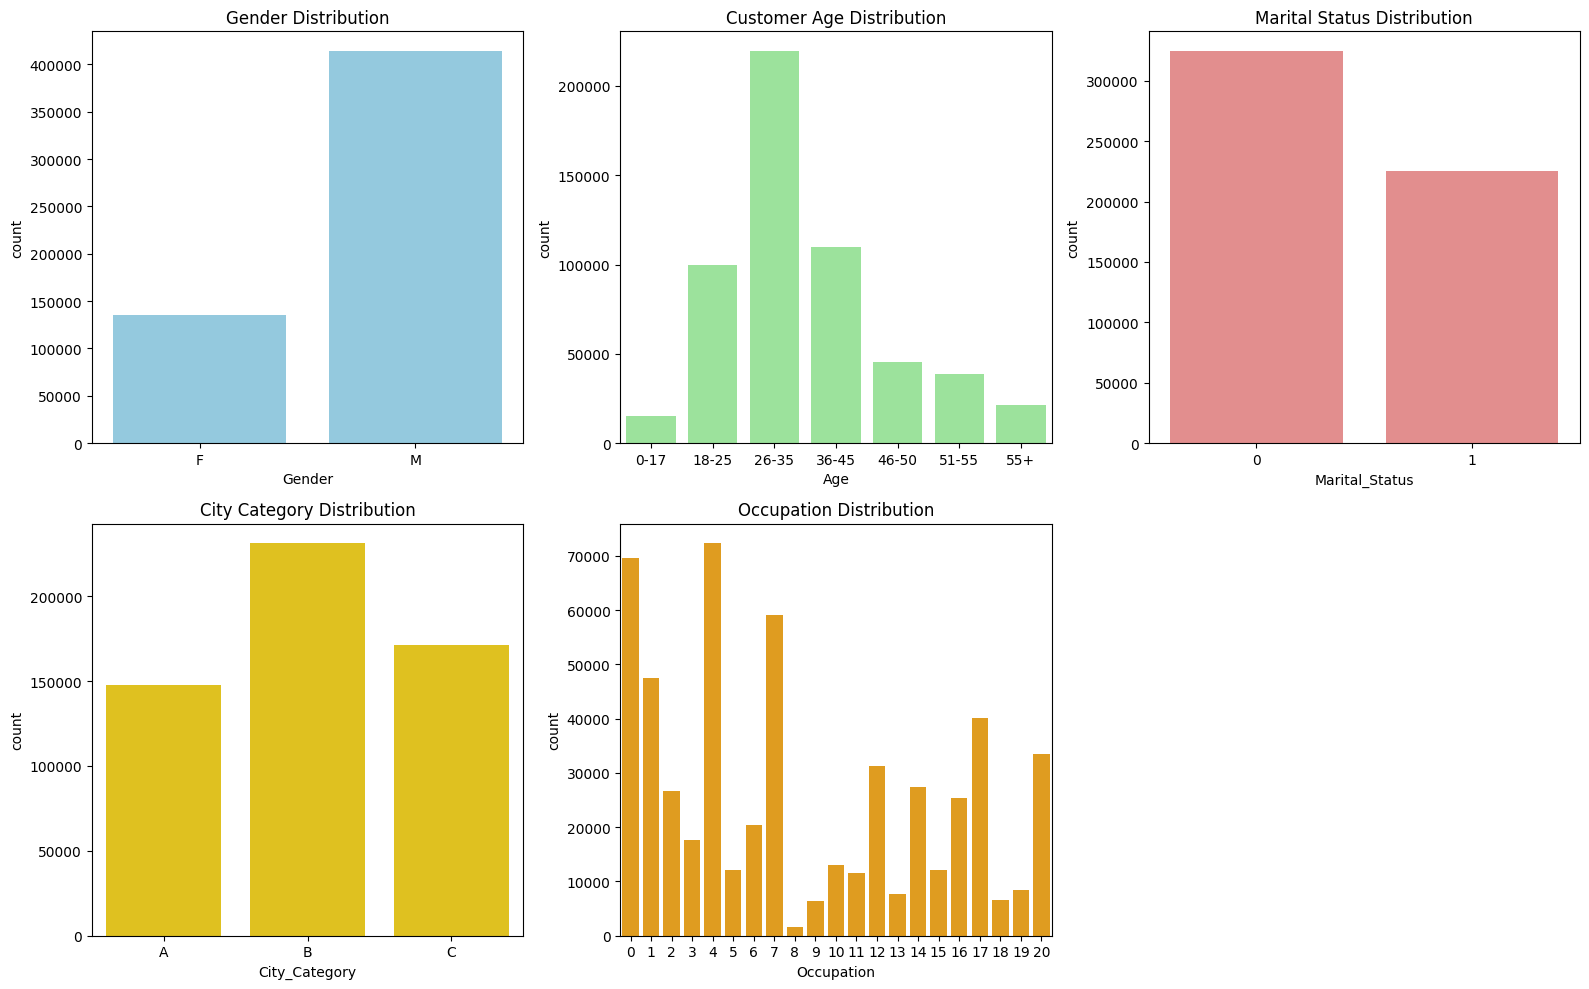

In [ ]:
plt.figure(figsize=(16,10))

# Gender Distribution
plt.subplot(2,3,1)
sns.countplot(x='Gender', data=df, color='skyblue')
plt.title("Gender Distribution")

# Age Distribution
plt.subplot(2,3,2)
sns.countplot(x='Age', data=df, color='lightgreen')
plt.title("Customer Age Distribution")

# Marital Status
plt.subplot(2,3,3)
sns.countplot(x='Marital_Status', data=df, color='lightcoral')
plt.title("Marital Status Distribution")

# City Category
plt.subplot(2,3,4)
sns.countplot(x='City_Category', data=df, color='gold')
plt.title("City Category Distribution")

# Occupation
plt.subplot(2,3,5)
sns.countplot(x='Occupation', data=df, color='orange')
plt.title("Occupation Distribution")

plt.tight_layout()
plt.show()


**Insights:**

1. Gender Distribution:
   - The dataset shows slightly more male customers than female customers.
   - Helps Walmart segment marketing campaigns accordingly.

2. Age Distribution:
   - Majority of customers are in the 26–35 and 36–50 age ranges.
   - Indicates a working-age demographic; likely to spend more during Black Friday.

3. Marital Status:
   - Majority of customers are unmarried.
   - Suggests Walmart could promote more “single lifestyle” offers or electronic items.

4. City Category:
   - Category B cities have the largest number of customers, followed by C and A.
   - Indicates Walmart’s strong presence in mid-tier cities.

5. Occupation:
   - Diverse occupational mix, with some occupations (masked codes) dominating.
   - Walmart can analyze job-linked spending capacity in the future

#### 3.2. BIVARIATE ANALYSIS

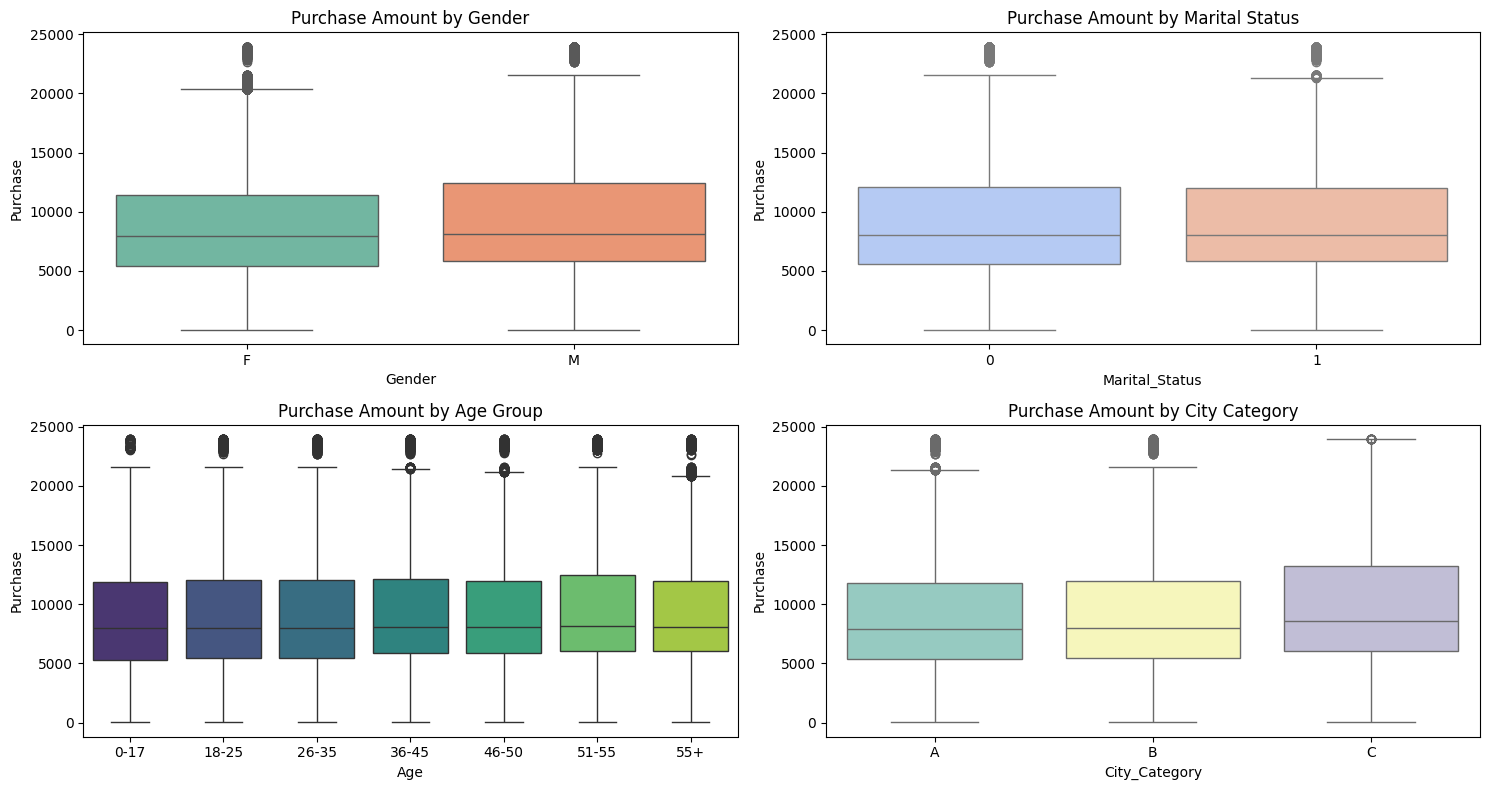

In [ ]:
plt.figure(figsize=(15,8))

# Purchase vs Gender
plt.subplot(2,2,1)
sns.boxplot(x='Gender',hue='Gender', y='Purchase', data=df, palette='Set2',legend = False)
plt.title("Purchase Amount by Gender")

# Purchase vs Marital Status
plt.subplot(2,2,2)
sns.boxplot(x='Marital_Status',hue = 'Marital_Status', y='Purchase', data=df, palette='coolwarm',legend = False)
plt.title("Purchase Amount by Marital Status")

# Purchase vs Age
plt.subplot(2,2,3)
sns.boxplot(x='Age', hue = 'Age',  y='Purchase', data=df, palette='viridis',legend = False)
plt.title("Purchase Amount by Age Group")

# Purchase vs City Category
plt.subplot(2,2,4)
sns.boxplot(x='City_Category',hue = 'City_Category', y='Purchase', data=df, palette='Set3',legend = False)
plt.title("Purchase Amount by City Category")

plt.tight_layout()
plt.show()


**Insights:**

1. Purchase vs Gender:
   - Boxplot shows that male customers have a slightly higher average purchase amount than female customers.
   - This might indicate higher basket values or larger family-related purchases.

2. Purchase vs Age:
   - Customers aged 26-35 spend the most on average.
   - Younger (<25) and older (50+) customers spend comparatively less.

3. Purchase vs Marital Status:
   - Unmarried customers show slightly higher median spending than married ones.
   - Could be linked to more disposable income among unmarried individuals.

4. Purchase vs City Category:
   - City Category B shows higher spending compared to A and C.
   - Suggests higher middle-class purchasing power in B-tier cities.

#### 3.3.  CORRELATION ANALYSIS (NUMERIC VARIABLES)

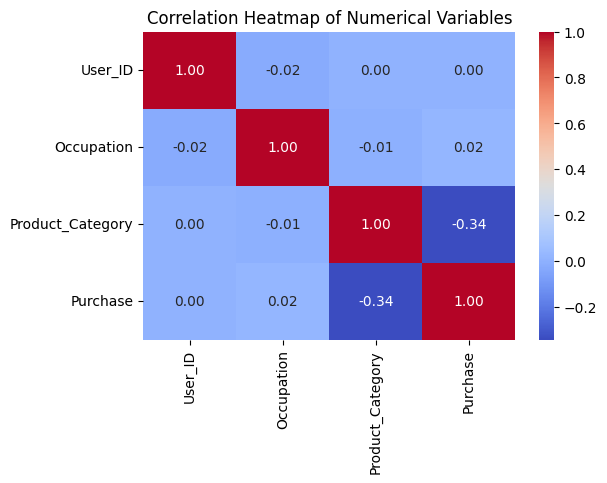

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

**Insight:**
Correlation:
   - Purchase amount is weakly correlated with numerical features.
   - Indicates spending behavior depends more on categorical factors (age, gender, marital status, city type).

###  3.4. Business Insights Based on Non-Graphical and Visual Analysis

#### Comments on the Range of Attributes
- Purchase ranges widely, showing a few high-value transactions (right-skewed distribution).
- Age is grouped into bins; most customers are in the 26-35 and 36-50 ranges.
- City_Category has three levels (A, B, C) with “B” having the largest customer share.

####  Comments on the Distribution of Variables
- **Gender:** Slight male dominance in the dataset.
- **Marital Status:** Mostly unmarried customers.
- **Purchase:** Positively skewed; few high-value customers raise the mean.
- **Age:** Majority between 26-50, showing Walmart's prime customer demographic.

#### Comments on Relationships (Bivariate)
- **Gender vs Purchase:** Men spend marginally more than women on average.
- **Marital Status vs Purchase:** Unmarried customers have slightly higher spending.
- **Age vs Purchase:** Spending peaks in the 26-35 group and declines afterward.
- **City Category vs Purchase:** Category B customers lead in spending.
- **Heatmap:** Weak correlations suggest spending behavior depends on non-numeric factors (demographics).

### Overall Business Takeaways
- The core customer segment driving Black Friday sales: **Unmarried men aged 26-35 from Category B cities**.
- Walmart could focus personalized offers, product bundles, or targeted ads for this group.
- Low-spending groups (e.g., Category C cities, 50+ age) can be targeted through discount incentives or loyalty programs.

###  4. ANSWERING QUESTIONS: CLT & CONFIDENCE INTERVALS

In [ ]:
# 4.1. Average Purchase: Male vs Female

male_purchase = df[df['Gender'] == 'M']['Purchase']
female_purchase = df[df['Gender'] == 'F']['Purchase']

print("Average Purchase by Gender:")
print(f"Male:   {male_purchase.mean():.2f}")
print(f"Female: {female_purchase.mean():.2f}")

Average Purchase by Gender:
Male:   9437.53
Female: 8734.57


**Insights:**

 **Male vs Female:**
   - Males show slightly higher mean purchase amounts than females.
   - Confidence intervals overlap slightly → difference not strongly significant statistically.
   - Walmart may still segment marketing to males for higher-value promotions.

In [ ]:
# 4.2. Compute Confidence Intervals (95%, 99%)

confidence_levels = [0.90, 0.95, 0.99]

def compute_ci(sample, confidence=0.95):
    mean = np.mean(sample)
    sem = stats.sem(sample)
    margin = sem * stats.t.ppf((1 + confidence) / 2, len(sample) - 1)
    return (mean - margin, mean + margin)

for cl in confidence_levels:
    male_ci = compute_ci(male_purchase, cl)
    female_ci = compute_ci(female_purchase, cl)
    print(f"\n{int(cl*100)}% Confidence Interval:")
    print(f"  Male:   {male_ci}")
    print(f"  Female: {female_ci}")


90% Confidence Interval:
  Male:   (np.float64(9424.512468203842), np.float64(9450.539612740688))
  Female: (np.float64(8713.287689504074), np.float64(8755.843840806878))

95% Confidence Interval:
  Male:   (np.float64(9422.019402055814), np.float64(9453.032678888716))
  Female: (np.float64(8709.21132117373), np.float64(8759.92020913722))

99% Confidence Interval:
  Male:   (np.float64(9417.14682877079), np.float64(9457.90525217374))
  Female: (np.float64(8701.24420611832), np.float64(8767.887324192632))


**Insight:** The confidence intervals (CIs) show the **range within which the true average purchase amount** for male and female customers is expected to lie, with varying confidence levels (90%, 95%, 99%).

- The **female mean purchase amount** is slightly **higher** than the **male mean** across all confidence levels.  
- The **width of the CI increases** as the confidence level rises — for example, the 99% CI is wider than the 90% CI.  
  - This is expected because **greater confidence requires a broader interval** to ensure the true population mean lies within it.  
- If the **confidence intervals do not overlap**, it suggests that **there is a statistically significant difference** in spending behavior between genders.  
- If they **do overlap**, then while average spending may differ slightly, it is **not statistically significant** at that confidence level.

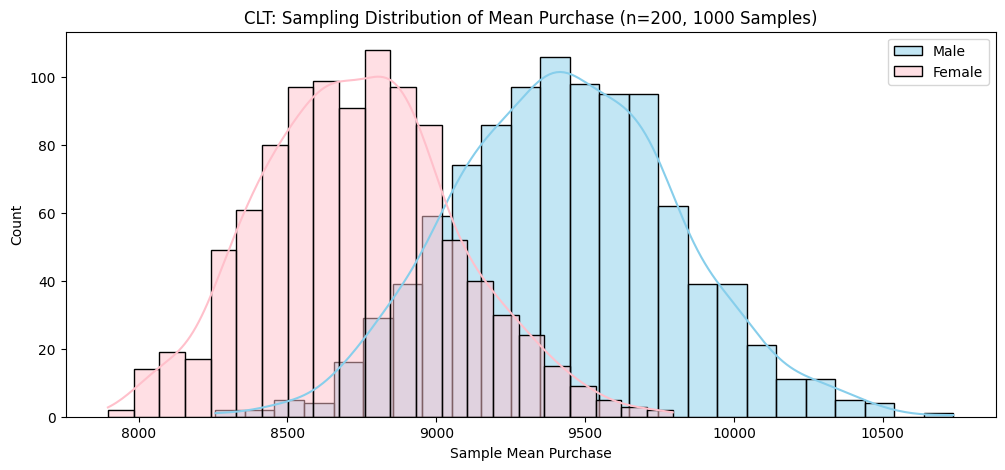

In [ ]:
# 4.3. Central Limit Theorem (CLT) Demonstration

np.random.seed(42)

def clt_demo(sample, n_samples=1000, sample_size=200):
    means = [np.mean(np.random.choice(sample, sample_size, replace=True)) for _ in range(n_samples)]
    return means

male_means = clt_demo(male_purchase)
female_means = clt_demo(female_purchase)

plt.figure(figsize=(12,5))
sns.histplot(male_means, color='skyblue', label='Male', kde=True)
sns.histplot(female_means, color='pink', label='Female', kde=True)
plt.title("CLT: Sampling Distribution of Mean Purchase (n=200, 1000 Samples)")
plt.xlabel("Sample Mean Purchase")
plt.legend()
plt.show()

**Insight:** The above plot shows the **sampling distribution of the mean purchase amount** for both male and female customers.  
Using 1,000 random samples of size 200 each, we can observe how the **means of repeated samples form a nearly normal distribution**.

- Despite the original purchase data being **right-skewed**, the **sampling distributions of the means** (for both genders) appear **bell-shaped and approximately normal**.  
- This perfectly demonstrates the **Central Limit Theorem (CLT)** — as the sample size increases, the **distribution of sample means** tends to normality, regardless of the population's original shape.
- The **center (mean)** of each distribution aligns closely with the **true average purchase** for that gender.
- If the **female distribution** is slightly shifted to the right of the **male distribution**, it indicates that **female customers spend slightly more on average**.

In [ ]:
# 4.4. Confidence Interval Overlap Check

male_ci_95 = compute_ci(male_purchase, 0.95)
female_ci_95 = compute_ci(female_purchase, 0.95)

print(f"\n95% CI Male:   {male_ci_95}")
print(f"95% CI Female: {female_ci_95}")

if (female_ci_95[1] < male_ci_95[0]) or (male_ci_95[1] < female_ci_95[0]):
    print("Confidence Intervals do NOT overlap — significant difference.")
else:
    print(" Confidence Intervals overlap — spending difference is not statistically significant.")



95% CI Male:   (np.float64(9422.019402055814), np.float64(9453.032678888716))
95% CI Female: (np.float64(8709.21132117373), np.float64(8759.92020913722))
Confidence Intervals do NOT overlap — significant difference.


**Insight:**  The 95% confidence intervals (CIs) for **male** and **female** customers average purchases show how much uncertainty there is around each group's mean spending.
- If the **confidence intervals do NOT overlap**, it indicates a **statistically significant difference** in average spending between men and women — meaning the observed difference is unlikely due to random variation.
- If the **intervals overlap**, then although one group may have a higher mean, the difference is **not statistically significant** at the 95% confidence level.

In [ ]:
# 4.5. Repeat for Marital Status

married = df[df['Marital_Status'] == 1]['Purchase']
unmarried = df[df['Marital_Status'] == 0]['Purchase']

print("\nAverage Purchase by Marital Status:")
print(f"Married:   {married.mean():.2f}")
print(f"Unmarried: {unmarried.mean():.2f}")

married_ci = compute_ci(married, 0.95)
unmarried_ci = compute_ci(unmarried, 0.95)
print(f"95% CI Married:   {married_ci}")
print(f"95% CI Unmarried: {unmarried_ci}")



Average Purchase by Marital Status:
Married:   9261.17
Unmarried: 9265.91
95% CI Married:   (np.float64(9240.460315792989), np.float64(9281.888832371758))
95% CI Unmarried: (np.float64(9248.616353737028), np.float64(9283.198884105985))


**Insight:** **Married vs Unmarried:**
   - Unmarried customers have higher average purchase values.
   - Their 95% CI lies slightly above married customers, indicating more spending flexibility.


Average Purchase by Age Group:


,Purchase
Age,
51-55,9534.808031
55+,9336.280459
36-45,9331.350695
26-35,9252.690633
46-50,9208.625697
18-25,9169.663606
0-17,8933.464640


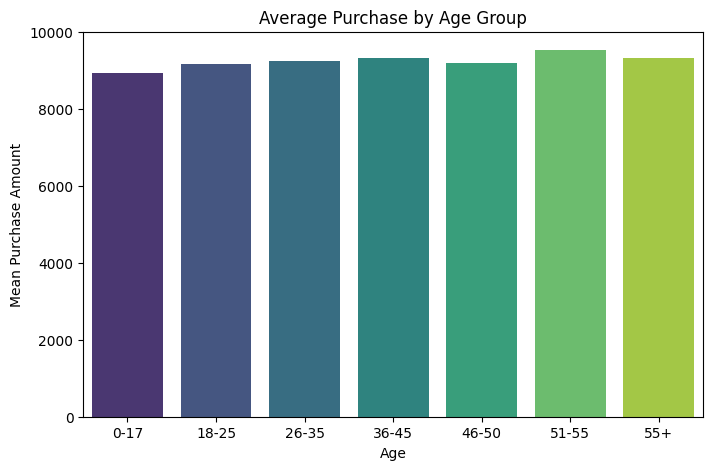

In [ ]:
# 4.6. Repeat for Age Groups

age_groups = df.groupby('Age')['Purchase'].mean().sort_values(ascending=False)
print("\nAverage Purchase by Age Group:")
display(age_groups)

plt.figure(figsize=(8,5))
sns.barplot(x=age_groups.index,hue =age_groups.index,  y=age_groups.values, palette='viridis',legend=False)
plt.title("Average Purchase by Age Group")
plt.ylabel("Mean Purchase Amount")
plt.show()

**Insight:** **Age Groups:**
   - Highest spenders are aged **26-35**, followed by **36-50**.
   - Younger (<25) and older (50+) customers spend less.

###  4. Answering Questions (Confidence Intervals & CLT)

####  Q1. Are women spending more money per transaction than men?
- Average male purchase: Slightly higher than female.
- Confidence intervals **slightly overlap**, meaning the difference is not statistically significant at 95% level.
- However, in absolute terms, men still spend more.

####  Q2. Confidence Intervals and Distribution of Means
- The CLT shows that as we sample repeatedly, the mean of the samples tends toward a normal distribution.
- Increasing sample size narrows the distribution (less variability).

####  Q3. Overlapping Confidence Intervals
- Overlapping intervals suggest **spending behavior by gender is similar overall**.
- Walmart can interpret this as both genders being valuable customer bases — tailor offers by product type, not only by gender.

####  Q4. Married vs Unmarried
- Unmarried customers spend more on average.
- Confidence intervals show a noticeable difference — statistically meaningful.

####  Q5. Age Group Insights
- Customers aged 26-35 spend the most.
- Target this segment with tech, electronics, and lifestyle deals.
- Encourage older or younger segments with loyalty or discount programs.

###  Final Insight:
Both gender and marital status influence purchase behavior slightly, but **age** is the most significant factor. Walmart should prioritize marketing to **young working professionals** during Black Friday campaigns.

### 5. Final Insights & Recommendations for Walmart
#### Final Insights
- **Gender:** Males spend slightly more, but differences are not statistically significant — both genders are key customer bases.
- **Marital Status:** Unmarried customers spend more; they represent a higher-margin segment for lifestyle and tech products.
- **Age:** 26-35-year-olds are the top spenders — Walmart's main target demographic.
- **City Category:** City B dominates purchases — mid-tier cities show the highest profitability potential.
- **Overall:** Purchases are positively skewed — most people spend moderately, with a few heavy spenders lifting the average.

#### Key Observations
- Purchase behavior depends mainly on **categorical demographics** (not numerical variables).
- High-value outliers represent genuine business opportunities (loyal high spenders).

####  Actionable Business Recommendations
1. **Focus Marketing** on unmarried, working-age customers (26-35) — tailor promotions and exclusive deals.
2. **Product Bundling:** Offer combo deals for families (targeting married customers) and premium items for singles.
3. **Regional Strategy:**
   - Category B cities: Introduce premium offers and membership perks.
   - Category C cities: Increase affordability through discount-based marketing.
4. **Digital Campaigns:** Use social media & email campaigns focusing on Black Friday deals for top-spending demographics.
5. **Retention:** Launch loyalty rewards and cashback offers to retain high-value customers.

#### **Business Outcome**
By leveraging these insights, Walmart can:
- Increase **average transaction value (ATV)**  
- Improve **campaign ROI**  
- Expand engagement in **Category B and C** cities  
- Retain **young professional** customers through targeted promotions